<a href="https://colab.research.google.com/github/farrelrassya/Feature-Engineering-for-Machine-Learning/blob/main/Ch01_The_Machine_Learning_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 1: The Machine Learning Pipeline

**Feature Engineering for Machine Learning** — *Alice Zheng & Amanda Casari*

---

This chapter sets the stage for the entire book by introducing the four foundational concepts that every feature engineering decision depends on: **data**, **tasks**, **models**, and **features**. Before we can engineer features well, we need a clear mental model of where features sit in the broader machine learning pipeline — and why the choice of features and models forms a "double-jointed lever" that determines the quality of our insights.

The chapter is deliberately non-technical. There is no code to optimize or metrics to chase. Instead, we build the conceptual vocabulary that the rest of the book assumes. Think of this as the architectural blueprint before construction begins.

## Environment Setup

In [ ]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("Environment ready.")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")

Environment ready.
NumPy version: 2.0.2
Matplotlib version: 3.10.0


Since Chapter 1 is a conceptual overview, we only need NumPy, Pandas, and Matplotlib for illustrations. The heavier libraries — scikit-learn, scipy, XGBoost — will appear from Chapter 2 onward when we work with real datasets and transformations.

## 1.1 Data

**Data** are observations of real-world phenomena. Each observation provides a small window into a limited aspect of reality. The collection of all observations gives us a picture of the whole — but that picture is messy. It is composed of thousands of little pieces, always contaminated by **measurement noise** and riddled with **missing pieces**.

Consider some concrete examples across domains:

| Domain | Example Observations |
|---|---|
| Finance | Daily stock prices, earnings announcements, analyst opinions |
| Health | Minute-by-minute heart rate, blood sugar, blood pressure |
| E-commerce | "Alice bought two books on Sunday," "Bob browsed these pages" |
| NLP | Product reviews, social media posts, support tickets |

The key insight is that data is inherently **heterogeneous** and **noisy**. No single observation tells the full story. The art of data science begins with acknowledging this messiness and developing systematic ways to extract signal from noise.

### Why Data Is Messy: A Quantitative Illustration

To make the concept of noise concrete, consider a toy example. Suppose we observe a simple linear relationship $y = 2x + 1$, but every measurement includes Gaussian noise with standard deviation $\sigma$. As $\sigma$ increases, the underlying pattern becomes harder to detect.

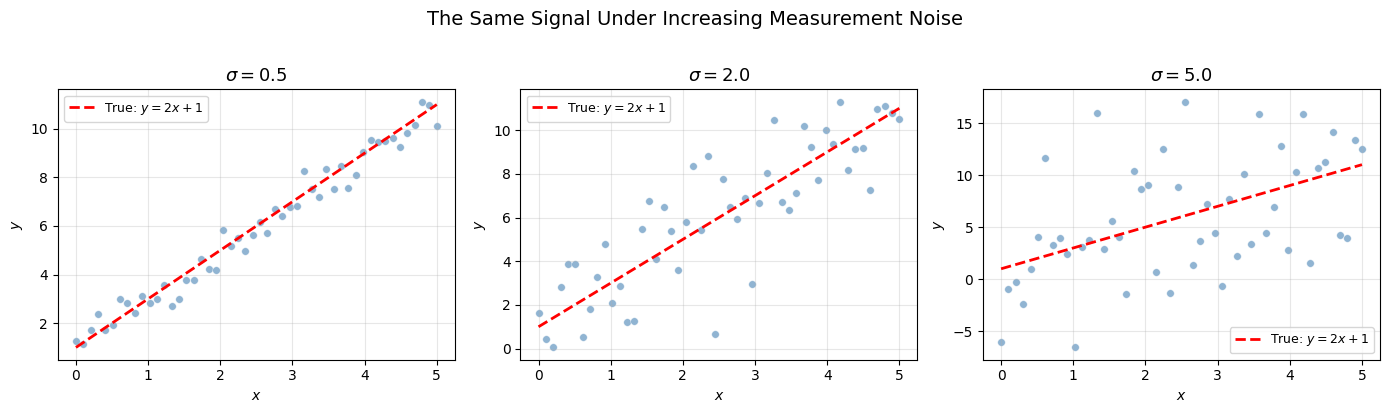

In [ ]:
np.random.seed(42)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
x = np.linspace(0, 5, 50)
y_true = 2 * x + 1
for ax, sigma in zip(axes, [0.5, 2.0, 5.0]):
    noise = np.random.normal(0, sigma, size=len(x))
    y_noisy = y_true + noise
    ax.scatter(x, y_noisy, alpha=0.6, s=30, color='steelblue', edgecolors='white', linewidths=0.5)
    ax.plot(x, y_true, 'r--', linewidth=2, label='True: $y = 2x + 1$')
    ax.set_title(f'$\\sigma = {sigma}$', fontsize=13)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
fig.suptitle('The Same Signal Under Increasing Measurement Noise', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

The three panels above show the exact same underlying relationship $y = 2x + 1$ observed with increasing noise levels $\sigma = 0.5, 2.0, 5.0$.

At $\sigma = 0.5$ (left), the linear trend is obvious — any reasonable model would recover it. At $\sigma = 2.0$ (center), the pattern is still discernible but requires more data or a more careful model. At $\sigma = 5.0$ (right), the noise dominates and the signal is nearly buried.

This is the fundamental challenge: **real-world data lives somewhere between the center and right panels**. Rarely do we get the clean left-panel scenario. The signal-to-noise ratio (SNR) quantifies this:

$$\text{SNR} = \frac{\text{Var}(\text{signal})}{\text{Var}(\text{noise})} = \frac{\text{Var}(2x + 1)}{\sigma^2}$$

For our example with $x \in [0, 5]$, the signal variance is $\text{Var}(2x+1) = 4 \cdot \text{Var}(x) \approx 4 \times 2.08 = 8.33$. The three panels have SNR $\approx 33.3$, $2.08$, and $0.33$, respectively. When SNR falls below 1, noise literally contains more energy than signal — and feature engineering becomes critical for extracting whatever information remains.

## 1.2 Tasks

We collect data because there are **questions** we want answered — questions like "Which stocks should I invest in?" or "How can I live a healthier lifestyle?" or "How can I understand my customers' changing tastes?"

In machine learning, these questions are formalized as **tasks**. Every ML task has the same basic structure:

$$\text{Task: Given input } \mathbf{x}, \text{ predict output } y$$

The path from data to answers is full of false starts and dead ends. What starts as a promising approach may not pan out. What was originally just a hunch may end up being the best solution. The authors describe this beautifully as **"the garden of bifurcating paths"** between data and answers (Figure 1-1 in the textbook).

### Common ML Task Types

Understanding the taxonomy of tasks helps us choose appropriate features later in the book:

| Task Type | Output $y$ | Example | Typical Loss Function |
|---|---|---|---|
| **Regression** | Continuous $y \in \mathbb{R}$ | Predict house price | $\text{MSE} = \frac{1}{n}\sum(y_i - \hat{y}_i)^2$ |
| **Binary Classification** | $y \in \{0, 1\}$ | Spam detection | $\text{Log loss} = -\frac{1}{n}\sum[y\log\hat{y} + (1-y)\log(1-\hat{y})]$ |
| **Multi-class Classification** | $y \in \{1, \ldots, K\}$ | Digit recognition | Cross-entropy |
| **Ranking** | Ordered list | Search results | NDCG, MAP |
| **Clustering** | Group assignments | Customer segmentation | Silhouette, inertia |

The choice of task dictates what kind of features are useful. A spam detector needs word-level features; a house price predictor needs square footage and location features. **The task is the compass that guides all subsequent feature engineering decisions.**

## 1.3 Models

A **model** is a mathematical description of the relationships between different aspects of the data. The authors use a vivid analogy: understanding the world through data is like "trying to piece together reality using a noisy, incomplete jigsaw puzzle with a bunch of extra pieces."

Models give us a principled way to handle data that is **wrong** (measurement mistakes), **redundant** (multiple aspects conveying the same information), or **missing** (absent for some observations).

### How Models Connect to Features

Mathematical formulas relate **numeric** quantities to each other. But raw data is often **not numeric**. The action "Alice bought *The Lord of the Rings* trilogy on Wednesday" is not a number. Something must bridge the gap between raw observations and mathematical models — and that bridge is **features**:

$$\hat{y}_{\text{price}} = f(\underbrace{x_1, x_2, \ldots, x_p}_{\text{features derived from earnings, history, industry, ...}})$$

The function $f$ is the model. The inputs $x_1, \ldots, x_p$ are the features. Neither exists in isolation; they are designed together.

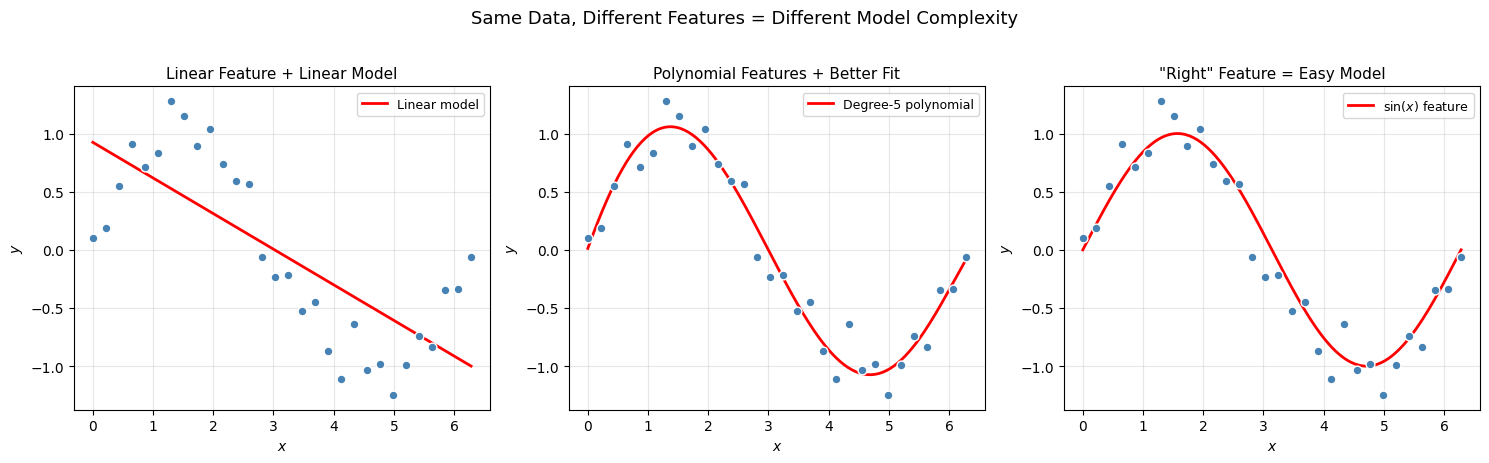

In [ ]:
np.random.seed(42)
x_raw = np.linspace(0, 2 * np.pi, 30)
y_raw = np.sin(x_raw) + np.random.normal(0, 0.2, 30)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
# Model 1: Linear
ax = axes[0]
ax.scatter(x_raw, y_raw, color='steelblue', s=40, edgecolors='white', zorder=3)
coeffs = np.polyfit(x_raw, y_raw, 1)
ax.plot(x_raw, np.polyval(coeffs, x_raw), 'r-', linewidth=2, label='Linear model')
ax.set_title('Linear Feature + Linear Model', fontsize=11)
ax.set_xlabel('$x$'); ax.set_ylabel('$y$'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
# Model 2: Polynomial
ax = axes[1]
ax.scatter(x_raw, y_raw, color='steelblue', s=40, edgecolors='white', zorder=3)
coeffs3 = np.polyfit(x_raw, y_raw, 5)
x_smooth = np.linspace(0, 2 * np.pi, 200)
ax.plot(x_smooth, np.polyval(coeffs3, x_smooth), 'r-', linewidth=2, label='Degree-5 polynomial')
ax.set_title('Polynomial Features + Better Fit', fontsize=11)
ax.set_xlabel('$x$'); ax.set_ylabel('$y$'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
# Model 3: Sinusoidal
ax = axes[2]
ax.scatter(x_raw, y_raw, color='steelblue', s=40, edgecolors='white', zorder=3)
ax.plot(x_smooth, np.sin(x_smooth), 'r-', linewidth=2, label='$\sin(x)$ feature')
ax.set_title('"Right" Feature = Easy Model', fontsize=11)
ax.set_xlabel('$x$'); ax.set_ylabel('$y$'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
fig.suptitle('Same Data, Different Features = Different Model Complexity', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

These three panels demonstrate the book's core thesis about the **feature-model interplay**:

**Left panel:** We use $x$ directly as the only feature and fit a linear model $\hat{y} = w_0 + w_1 x$. The fit is poor because a straight line cannot capture the sinusoidal pattern. The feature is too simple for the data.

**Center panel:** We engineer polynomial features $[x, x^2, x^3, x^4, x^5]$ and fit a degree-5 polynomial. The fit improves dramatically — but we needed 5 features and a more complex model to get there.

**Right panel:** If we know (or discover) that the true relationship is sinusoidal, we can create a single feature $\sin(x)$ and fit the trivially simple model $\hat{y} = a \cdot \sin(x) + b$. One well-chosen feature replaces five polynomial features.

This is the central lesson of feature engineering: **good features make simple models powerful, while poor features force us into complex models** that are harder to train, interpret, and deploy. The authors capture this as a "double-jointed lever" — you can turn either the feature knob or the model knob, and each affects the other.

## 1.4 Features

A **feature** is a numeric representation of raw data. This definition is deceptively simple. The word "representation" carries enormous weight — *how* we represent data numerically determines what patterns a model can discover.

Feature engineering is the process of formulating the most appropriate features given three constraints: (1) **the data** available, (2) **the model** being used, and (3) **the task** at hand.

The number of features matters critically. Too few features means the model cannot learn — **underfitting**. Too many irrelevant features means training is expensive and error-prone — **overfitting**. The right number lives in between.

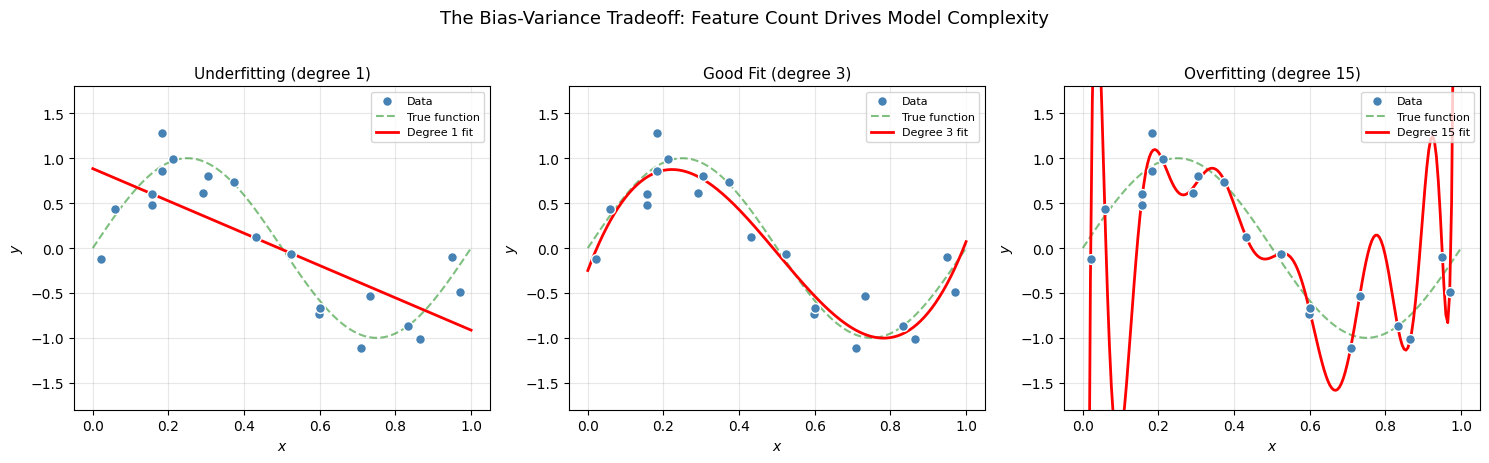

In [ ]:
np.random.seed(42)
n = 20
x = np.sort(np.random.uniform(0, 1, n))
y_true_fn = np.sin(2 * np.pi * x)
y = y_true_fn + np.random.normal(0, 0.25, n)
x_plot = np.linspace(0, 1, 200)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
titles = ['Underfitting (degree 1)', 'Good Fit (degree 3)', 'Overfitting (degree 15)']
degrees = [1, 3, 15]
for ax, deg, title in zip(axes, degrees, titles):
    coeffs = np.polyfit(x, y, deg)
    y_pred = np.polyval(coeffs, x_plot)
    ax.scatter(x, y, color='steelblue', s=50, edgecolors='white', zorder=3, label='Data')
    ax.plot(x_plot, np.sin(2 * np.pi * x_plot), 'g--', alpha=0.5, linewidth=1.5, label='True function')
    ax.plot(x_plot, y_pred, 'r-', linewidth=2, label=f'Degree {deg} fit')
    ax.set_title(title, fontsize=11)
    ax.set_ylim(-1.8, 1.8)
    ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
    ax.legend(fontsize=8, loc='upper right'); ax.grid(True, alpha=0.3)
fig.suptitle('The Bias-Variance Tradeoff: Feature Count Drives Model Complexity', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

This classic demonstration connects directly to the book's warning about feature count:

**Left (Underfitting):** A degree-1 polynomial (1 feature: $x$) cannot capture the sinusoidal curve. The model has **high bias**. No matter how much data we collect, a straight line will never fit a sine wave.

**Center (Good Fit):** A degree-3 polynomial (3 features: $x, x^2, x^3$) captures the shape well without chasing noise. This is the sweet spot where the model has enough capacity to represent the signal but not enough flexibility to memorize noise.

**Right (Overfitting):** A degree-15 polynomial (15 features: $x, x^2, \ldots, x^{15}$) passes through nearly every data point but produces wild oscillations between them. The model has **high variance** — it would produce a completely different curve with a different random sample.

This tradeoff is formalized by the **bias-variance decomposition** of prediction error:

$$\text{Expected Error} = \underbrace{\text{Bias}^2}_{\text{systematic error}} + \underbrace{\text{Variance}}_{\text{sensitivity to training data}} + \underbrace{\sigma^2}_{\text{irreducible noise}}$$

Feature engineering aims to minimize the sum of the first two terms. The third term $\sigma^2$ is the noise floor — no model or feature can remove it.

## 1.5 The Machine Learning Pipeline

The authors present a clean pipeline (Figure 1-2 in the textbook):

$$\boxed{\text{Raw Data}} \xrightarrow{\text{Clean \& Transform}} \boxed{\text{Features}} \xrightarrow{\text{Model}} \boxed{\text{Insights}}$$

Each stage has its own failure modes and engineering decisions:

| Stage | Key Decisions | Failure Mode |
|---|---|---|
| **Select & Merge** | Which data sources? How to join? | Missing joins, schema mismatches |
| **Clean & Transform** | Handle nulls, outliers, types | Leaking test info, destroying signal |
| **Feature Engineering** | Representation, granularity, interactions | Too few / too many / wrong features |
| **Modeling** | Algorithm choice, hyperparameters | Underfitting, overfitting, wrong metric |

**Feature engineering sits at the center of this pipeline.** It is the bridge between messy raw data and the structured numeric inputs that models require.

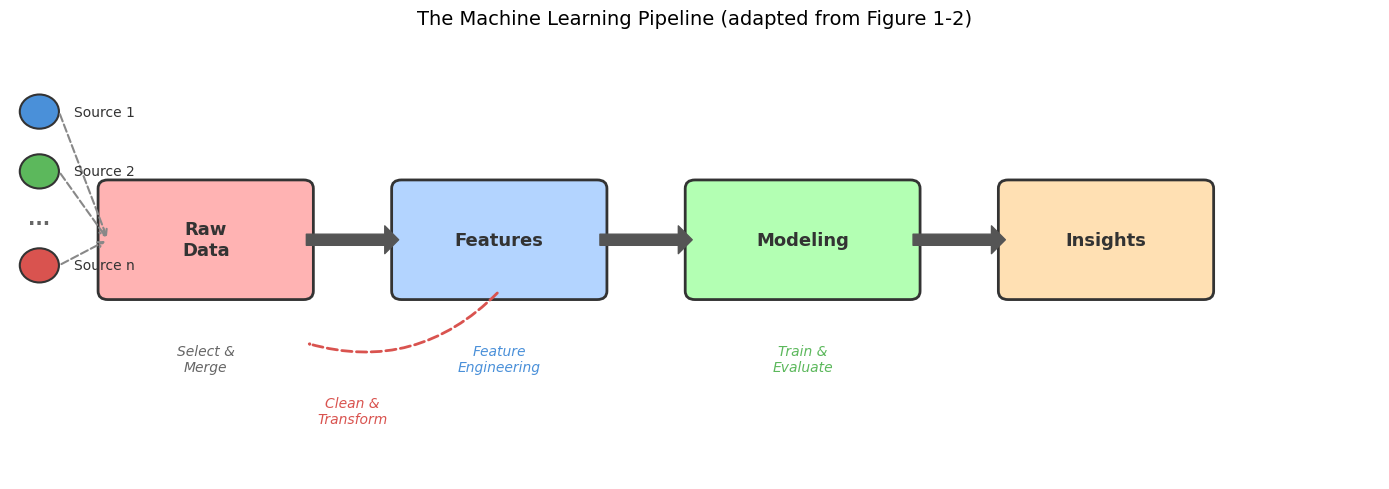

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 14)
ax.set_ylim(0, 5)
ax.axis('off')
# Pipeline boxes
boxes = [
    (1.0, 2.2, 2.0, 1.2, '#FFB3B3', 'Raw\nData'),
    (4.0, 2.2, 2.0, 1.2, '#B3D4FF', 'Features'),
    (7.0, 2.2, 2.2, 1.2, '#B3FFB3', 'Modeling'),
    (10.2, 2.2, 2.0, 1.2, '#FFE0B3', 'Insights'),
]
for bx, by, bw, bh, color, label in boxes:
    rect = FancyBboxPatch((bx, by), bw, bh, boxstyle="round,pad=0.1",
                           facecolor=color, edgecolor='#333333', linewidth=2)
    ax.add_patch(rect)
    ax.text(bx + bw/2, by + bh/2, label, ha='center', va='center',
            fontsize=13, fontweight='bold', color='#333333')
# Arrows
arrow_kw = dict(arrowstyle='Simple,tail_width=8,head_width=20,head_length=10', color='#555555')
for xs, xe in [(3.0, 4.0), (6.0, 7.0), (9.2, 10.2)]:
    ax.add_patch(FancyArrowPatch((xs, 2.8), (xe, 2.8), **arrow_kw))
# Source nodes
for label, sx, sy, color in [('Source 1', 0.3, 4.3, '#4A90D9'), ('Source 2', 0.3, 3.6, '#5CB85C'), ('Source n', 0.3, 2.5, '#D9534F')]:
    ax.add_patch(plt.Circle((sx, sy), 0.2, color=color, ec='#333333', linewidth=1.5))
    ax.text(sx + 0.35, sy, label, va='center', fontsize=10, color='#333333')
    ax.annotate('', xy=(1.0, 2.8), xytext=(sx + 0.2, sy),
                arrowprops=dict(arrowstyle='->', color='#888888', lw=1.5, ls='--'))
ax.text(0.3, 3.05, '...', ha='center', va='center', fontsize=14, fontweight='bold', color='#666666')
# Stage labels
for lx, ly, label, color in [(2.0, 1.4, 'Select &\nMerge', '#666'), (3.5, 0.8, 'Clean &\nTransform', '#D9534F'), (5.0, 1.4, 'Feature\nEngineering', '#4A90D9'), (8.1, 1.4, 'Train &\nEvaluate', '#5CB85C')]:
    ax.text(lx, ly, label, ha='center', va='center', fontsize=10, fontstyle='italic', color=color)
# Feedback loop
ax.add_patch(FancyArrowPatch((5.0, 2.2), (3.0, 1.6), connectionstyle="arc3,rad=-0.3",
                              arrowstyle='->', color='#D9534F', lw=2, ls='--'))
ax.set_title('The Machine Learning Pipeline (adapted from Figure 1-2)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

The pipeline diagram above adapts Figure 1-2 from the textbook. Notice several important structural properties:

**Multiple data sources** feed into the pipeline (Sources 1 through $n$). In practice, a stock price prediction system might combine exchange data, earnings reports, news sentiment, and macroeconomic indicators — each with different schemas, granularities, and update frequencies. The "Select & Merge" step is often the most time-consuming phase of a real project.

**The feedback loop** (dashed red arrow) between Features and Clean/Transform reflects the iterative nature of feature engineering. You rarely get features right on the first pass. Examining model errors often reveals that a feature needs different preprocessing — perhaps a log transform, a different binning strategy, or additional null handling.

**Feature engineering is the bottleneck.** The Raw Data stage is constrained by what data exists; the Modeling stage benefits from decades of well-packaged algorithms in libraries like scikit-learn. But the Features stage requires *domain knowledge*, *creativity*, and *systematic methodology* — which is precisely what this book teaches.

## 1.6 The Double-Jointed Lever: Features and Models

The book's most powerful metaphor is that features and models form a **double-jointed lever**. The choice of one affects the other, and adjusting either can improve performance:

$$\text{Performance} = g(\underbrace{\text{Features}}_{\text{knob 1}}, \underbrace{\text{Model}}_{\text{knob 2}})$$

**If your features are excellent,** even a simple model (logistic regression, Naive Bayes) can achieve strong results. **If your features are poor,** you need a complex model (deep neural network, gradient-boosted ensemble) that can discover patterns internally. But complexity comes with costs: longer training, more data required, harder interpretability, greater risk of overfitting.

The central argument of this book is: **invest in features first, complexity second.**

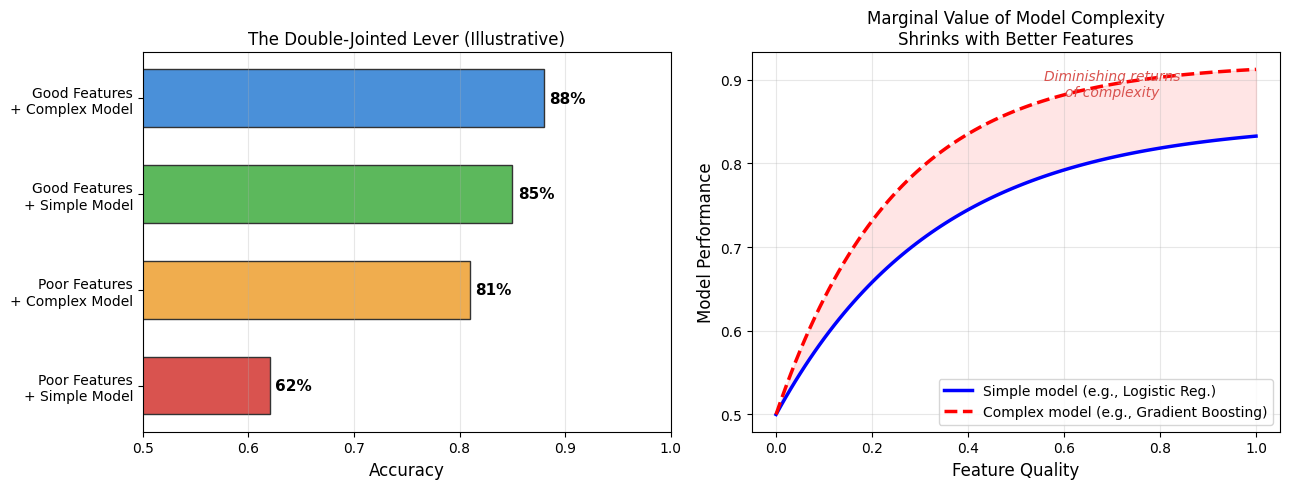

In [ ]:
np.random.seed(42)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# Left: Bar chart
categories = ['Poor Features\n+ Simple Model', 'Poor Features\n+ Complex Model',
              'Good Features\n+ Simple Model', 'Good Features\n+ Complex Model']
accuracies = [0.62, 0.81, 0.85, 0.88]
colors_bar = ['#D9534F', '#F0AD4E', '#5CB85C', '#4A90D9']
bars = axes[0].barh(categories, accuracies, color=colors_bar, edgecolor='#333333', height=0.6)
axes[0].set_xlim(0.5, 1.0)
axes[0].set_xlabel('Accuracy', fontsize=12)
axes[0].set_title('The Double-Jointed Lever (Illustrative)', fontsize=12)
for bar, acc in zip(bars, accuracies):
    axes[0].text(acc + 0.005, bar.get_y() + bar.get_height()/2,
                f'{acc:.0%}', va='center', fontsize=11, fontweight='bold')
axes[0].grid(True, axis='x', alpha=0.3)
# Right: Curves
fq = np.linspace(0, 1, 100)
simple_m = 0.5 + 0.35 * (1 - np.exp(-3 * fq))
complex_m = 0.5 + 0.42 * (1 - np.exp(-4 * fq))
axes[1].plot(fq, simple_m, 'b-', linewidth=2.5, label='Simple model (e.g., Logistic Reg.)')
axes[1].plot(fq, complex_m, 'r--', linewidth=2.5, label='Complex model (e.g., Gradient Boosting)')
axes[1].fill_between(fq, simple_m, complex_m, alpha=0.1, color='red')
axes[1].annotate('Diminishing returns\nof complexity', xy=(0.7, 0.88), fontsize=10,
                color='#D9534F', fontstyle='italic', ha='center')
axes[1].set_xlabel('Feature Quality', fontsize=12)
axes[1].set_ylabel('Model Performance', fontsize=12)
axes[1].set_title('Marginal Value of Model Complexity\nShrinks with Better Features', fontsize=12)
axes[1].legend(fontsize=10, loc='lower right')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The two panels above illustrate the double-jointed lever with simulated data (exact numbers are illustrative, not from a specific experiment):

**Left panel:** Four scenarios showing the interplay between feature quality and model complexity. Notice that **Good Features + Simple Model (85%)** outperforms **Poor Features + Complex Model (81%)**. This is the book's central claim: feature quality often matters more than model sophistication. The marginal gain from upgrading to a complex model with good features (85% to 88%) is only 3 percentage points — often not worth the added cost in training time, interpretability, and maintenance.

**Right panel:** As feature quality improves (moving right on the x-axis), the gap between simple and complex models narrows. The shaded region represents the "value of complexity" — it is widest when features are poor and nearly vanishes when features are excellent. In the limit of perfect features, the choice of model barely matters.

This is why experienced practitioners spend roughly 80% of their time on data cleaning and feature engineering, and only 20% on modeling. The rest of this book makes that 80% as productive as possible.

## 1.7 A Concrete Example: From Raw Data to Features

To anchor the abstract concepts in something tangible, let us walk through a miniature feature engineering exercise. Consider an e-commerce dataset with purchase records:

> "Alice bought The Lord of the Rings trilogy on Wednesday"

This sentence contains rich information, but a model cannot consume it as-is. We need to engineer numeric features.

In [ ]:
raw_data = pd.DataFrame({
    'customer': ['Alice', 'Bob', 'Charlie', 'Alice', 'Bob'],
    'item': ['Lord of the Rings', 'Harry Potter', 'Lord of the Rings', 'Dune', 'Lord of the Rings'],
    'day': ['Wednesday', 'Monday', 'Friday', 'Saturday', 'Wednesday'],
    'quantity': [1, 2, 1, 1, 3],
    'price': [29.99, 19.99, 29.99, 14.99, 29.99]
})
print("Raw Purchase Data:")
print(raw_data.to_string(index=False))
print(f"\nShape: {raw_data.shape[0]} rows x {raw_data.shape[1]} columns")

Raw Purchase Data:
customer              item       day  quantity  price
   Alice Lord of the Rings Wednesday         1  29.99
     Bob      Harry Potter    Monday         2  19.99
 Charlie Lord of the Rings    Friday         1  29.99
   Alice              Dune  Saturday         1  14.99
     Bob Lord of the Rings Wednesday         3  29.99

Shape: 5 rows x 5 columns


The raw data has **5 rows** and **5 columns**. Every field except `quantity` and `price` is categorical — strings that a mathematical model cannot directly process. Feature engineering transforms this into a numeric matrix.

In [ ]:
customer_features = raw_data.groupby('customer').agg(
    total_spend=('price', lambda x: (x * raw_data.loc[x.index, 'quantity']).sum()),
    total_items=('quantity', 'sum'),
    unique_items=('item', 'nunique'),
    num_transactions=('item', 'count')
).reset_index()
print("Engineered Customer Features:")
print(customer_features.to_string(index=False))
print(f"\nWe now have {customer_features.shape[1] - 1} numeric features per customer.")
print("These can be directly fed into any ML model.")

Engineered Customer Features:
customer  total_spend  total_items  unique_items  num_transactions
   Alice        44.98            2             2                 2
     Bob       129.95            5             2                 2
 Charlie        29.99            1             1                 1

We now have 4 numeric features per customer.
These can be directly fed into any ML model.


From 5 raw purchase records with mixed string-and-numeric fields, we engineered **4 clean numeric features** per customer. Bob's `total_spend` reflects his 2 Harry Potter books at \$19.99 and 3 Lord of the Rings copies at \$29.99. These features are now ready for clustering ("which customers are similar?"), classification ("will this customer churn?"), or regression ("how much will they spend next month?").

This tiny example illustrates the core workflow that the rest of the book scales up to real-world complexity: **raw observations to numeric representations to model-ready features**.

## 1.8 What Comes Next: A Roadmap

The rest of the book systematically covers the major feature engineering techniques:

| Chapter | Topic | Key Question |
|---|---|---|
| 2 | Fancy Tricks with Simple Numbers | How do we handle numeric features (scaling, binning, log transforms)? |
| 3 | Text Data: Flattening, Filtering, and Chunking | How do we convert text into numeric vectors? |
| 4 | The Effects of Feature Scaling | Why does scaling matter, and when? |
| 5 | Categorical Variables | How do we encode categories (one-hot, target encoding, hashing)? |
| 6 | Dimensionality Reduction | What if we have too many features? |
| 7 | Nonlinear Featurization via K-Means | How do we create features that capture nonlinear relationships? |
| 8 | Automating the Featurizer | Can models engineer their own features? |
| 9 | Back to the Feature | A full end-to-end case study |

Each chapter builds on the foundation established here: the interplay between data, features, models, and tasks. The double-jointed lever metaphor will recur throughout — every technique we learn is another way to turn the feature knob.

## 1.9 Key Takeaways

**Data** are observations of real-world phenomena — always noisy, often incomplete, and typically heterogeneous across sources.

**Tasks** formalize the questions we want data to answer. The task type (regression, classification, ranking, clustering) constrains which features are useful and which models are appropriate.

**Models** are mathematical descriptions of relationships in the data. They require numeric inputs, which raw data rarely provides directly.

**Features** are the numeric bridge between raw data and models. Feature engineering — the process of crafting these representations — is the central subject of this book and, arguably, the most impactful phase of the ML pipeline.

**The Double-Jointed Lever:** Features and models are interdependent. Good features simplify modeling; poor features necessitate complexity. Investing in features first yields the highest return on effort.

**The Pipeline:** Real ML workflows are iterative and messy. Data flows through selection, merging, cleaning, transformation, feature engineering, modeling, and evaluation — with feedback loops at every stage.

---

*In the next chapter, we begin engineering features in earnest, starting with the most fundamental data type: simple numeric quantities.*